In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
df = pd.read_csv("../data/creditcard.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [3]:
df.shape

(284807, 31)

In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [7]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [8]:
fraud = df[df["Class"] == 1].shape[0]
genuine = df[df["Class"] == 0].shape[0]

print("Fraud Transactions:", fraud)
print("Genuine Transactions:", genuine)

fraud_percentage = (fraud / len(df)) * 100

print("Fraud Percentage:", round(fraud_percentage, 4), "%")

Fraud Transactions: 492
Genuine Transactions: 284315
Fraud Percentage: 0.1727 %


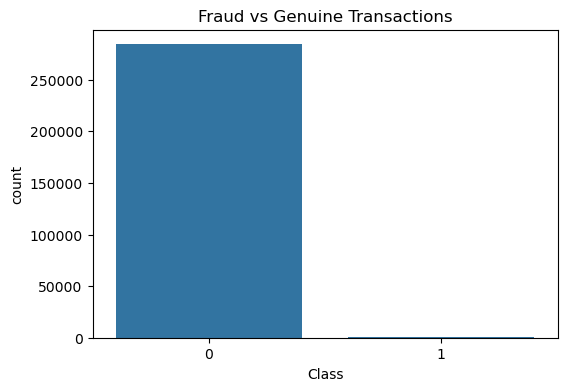

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(x="Class", data=df)

plt.title("Fraud vs Genuine Transactions")
plt.show()

In [10]:
df["Amount"].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

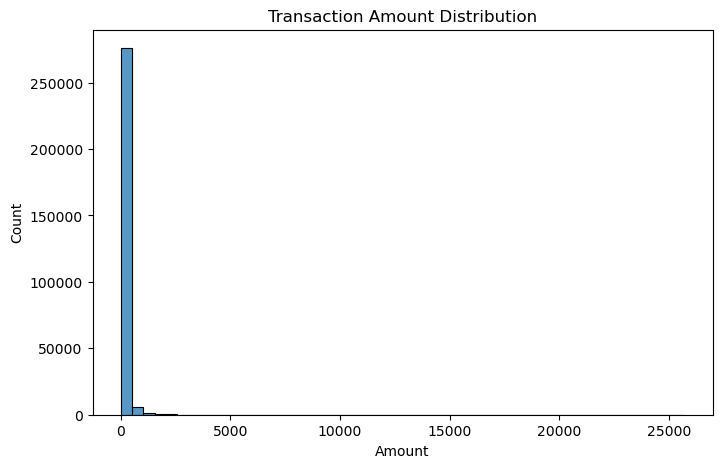

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(df["Amount"], bins=50)

plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Count")

plt.show()

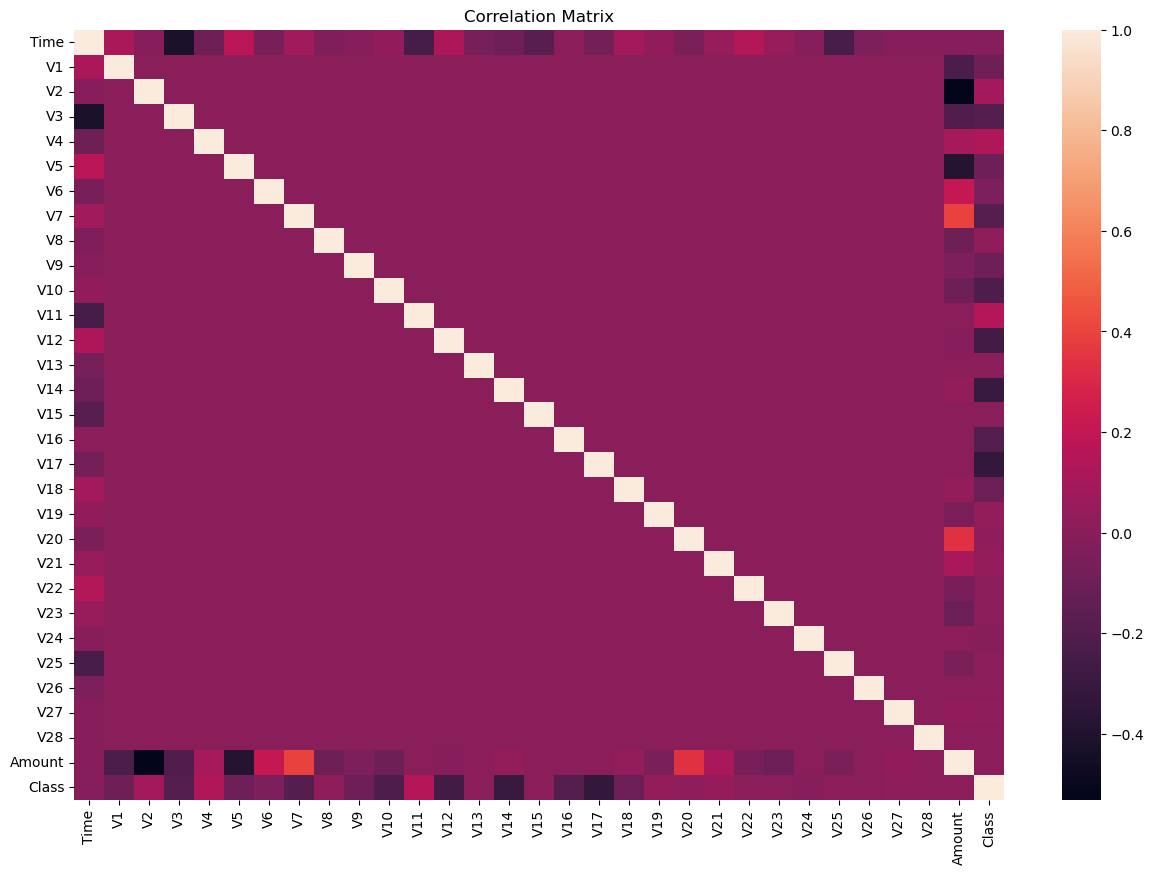

In [12]:
plt.figure(figsize=(15,10))

sns.heatmap(df.corr())

plt.title("Correlation Matrix")

plt.show()

In [13]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (284807, 30)
Target Shape: (284807,)


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df["Amount"] = scaler.fit_transform(df[["Amount"]])

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244964,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342475,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.160686,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.140534,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073403,0


In [15]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (227845, 30)
Testing Data: (56962, 30)


In [17]:
print(y_train.value_counts())

Class
0    227451
1       394
Name: count, dtype: int64


In [18]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("After SMOTE")

print(y_train_smote.value_counts())

After SMOTE
Class
0    227451
1    227451
Name: count, dtype: int64


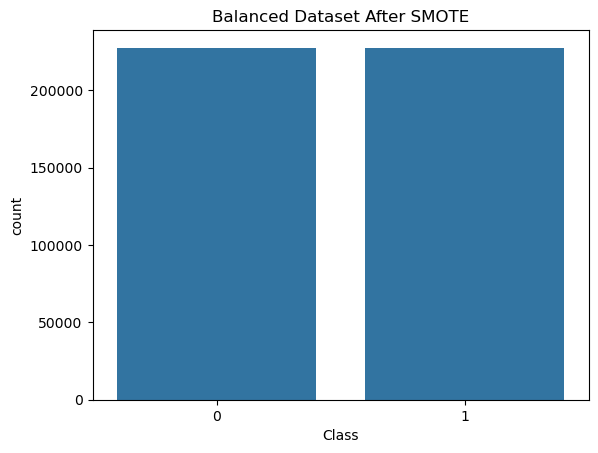

In [19]:
sns.countplot(x=y_train_smote)

plt.title("Balanced Dataset After SMOTE")
plt.show()

In [20]:
from sklearn.linear_model import LogisticRegression

In [21]:
lr_model = LogisticRegression(random_state=42)

lr_model.fit(X_train_smote, y_train_smote)

print("Model Trained Successfully")

Model Trained Successfully


In [22]:
y_pred = lr_model.predict(X_test)

In [23]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9826726589656262


In [24]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.08      0.91      0.15        98

    accuracy                           0.98     56962
   macro avg       0.54      0.95      0.57     56962
weighted avg       1.00      0.98      0.99     56962



In [25]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[55886   978]
 [    9    89]]


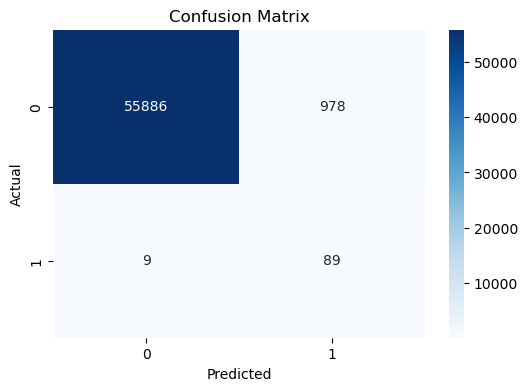

In [26]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [27]:
from sklearn.ensemble import RandomForestClassifier

In [29]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=20,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_smote, y_train_smote)

print("Random Forest Trained Successfully")

Random Forest Trained Successfully


In [30]:
rf_pred = rf_model.predict(X_test)

In [31]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print("Accuracy:", rf_accuracy)

Accuracy: 0.9981039991573329


In [32]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    rf_pred
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.47      0.88      0.61        98

    accuracy                           1.00     56962
   macro avg       0.74      0.94      0.81     56962
weighted avg       1.00      1.00      1.00     56962



In [33]:
from sklearn.metrics import confusion_matrix

rf_cm = confusion_matrix(
    y_test,
    rf_pred
)

print(rf_cm)

[[56768    96]
 [   12    86]]


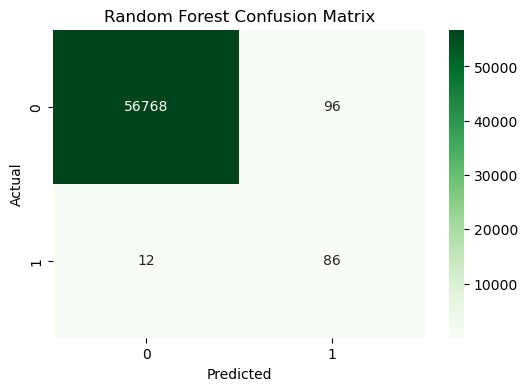

In [34]:
plt.figure(figsize=(6,4))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [35]:
import joblib

joblib.dump(rf_model, "../models/fraud_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [36]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
14,V14,0.344016
17,V17,0.154974
12,V12,0.084457
4,V4,0.084068
10,V10,0.078463
3,V3,0.078136
16,V16,0.032863
2,V2,0.026106
9,V9,0.025395
11,V11,0.011894


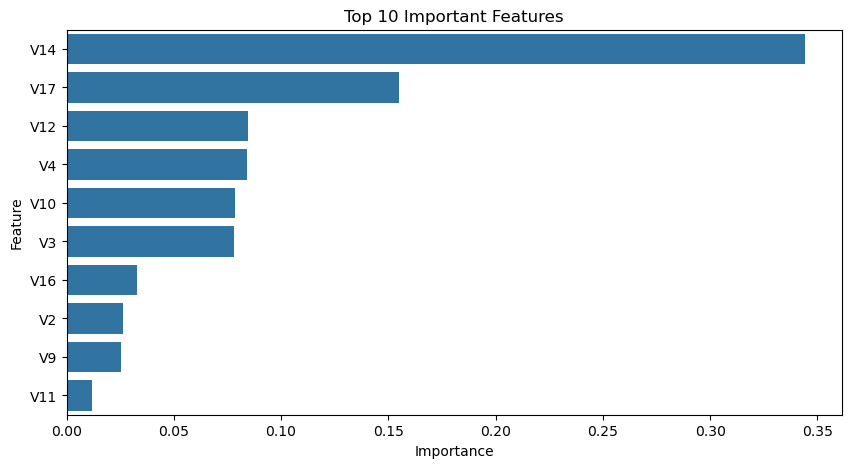

In [37]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(10)
)

plt.title("Top 10 Important Features")

plt.show()

In [38]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [0.9827, 0.9981],
    "Fraud Recall": [0.91, 0.88],
    "Fraud Precision": [0.08, 0.47]
})

results

,Model,Accuracy,Fraud Recall,Fraud Precision
0,Logistic Regression,0.9827,0.91,0.08
1,Random Forest,0.9981,0.88,0.47


In [39]:
import os

print(os.listdir("../app"))

['.ipynb_checkpoints', 'app.py.txt']


In [40]:
import os

os.rename("../app/app.py.txt", "../app/app.py")

print("Renamed Successfully")

Renamed Successfully


In [41]:
import os

print(os.listdir("../app"))

['.ipynb_checkpoints', 'app.py']


In [43]:
!pip show streamlit

Name: streamlit
Version: 1.51.0
Summary: A faster way to build and share data apps
Home-page: https://streamlit.io
Author: Snowflake Inc
Author-email: hello@streamlit.io
License: Apache License 2.0
Location: C:\Users\navya\anaconda3\Lib\site-packages
Requires: altair, blinker, cachetools, click, gitpython, numpy, packaging, pandas, pillow, protobuf, pyarrow, requests, tenacity, toml, tornado, typing-extensions, watchdog
Required-by: 


In [44]:
import os

print(os.getcwd())

C:\Users\navya\credit-card-fraud-detection\notebooks


In [45]:
import os

print(os.listdir("../models"))

['fraud_model.pkl']


In [1]:
!streamlit run ../app/app.py

^C


In [2]:
with st.sidebar:
    st.header("Project Information")
    st.write("Model: Random Forest")
    st.write("Accuracy: 99.81%")
    st.write("Fraud Recall: 88%")

NameError: name 'st' is not defined

In [ ]:
col1, col2 = st.columns(2)

with col1:
    st.metric(
        "Fraud Probability",
        f"{fraud_prob:.2f}%"
    )

with col2:
    st.metric(
        "Genuine Probability",
        f"{genuine_prob:.2f}%"
    )

In [ ]:
print(X_test.iloc[0])